In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/covid_data.csv")
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,4.418200e+04,43982.000000,43200.000000,44182.000000,43982.000000,43200.000000,43918.000000,43918.000000,43135.000000,43918.000000,...,39442.000000,26322.000000,39967.000000,41366.000000,31358.000000,30963.000000,18658.000000,36139.000000,43963.000000,38558.000000
mean,9.372153e+04,1388.770224,1372.258368,3885.163189,43.323360,43.329499,1778.176471,23.573850,23.160618,55.320410,...,20979.943732,12.029018,251.347231,8.048869,10.834007,32.637049,52.576272,3.115428,74.052595,0.725580
std,9.707004e+05,12665.458657,12420.794948,36227.966483,366.554434,356.193423,3814.416468,72.289186,55.613758,140.662359,...,20466.166309,19.158253,117.620708,4.143192,10.481952,13.408593,31.579386,2.530433,7.364382,0.152673
min,0.000000e+00,-8261.000000,-552.000000,0.000000,-1918.000000,-232.143000,0.000000,-2212.545000,-269.978000,0.000000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.354000
25%,5.300000e+01,0.000000,0.571000,0.000000,0.000000,0.000000,25.373750,0.000000,0.123000,0.000000,...,5338.454000,0.500000,155.898000,5.310000,1.900000,21.400000,21.222000,1.300000,69.910000,0.606000
50%,9.370000e+02,9.000000,14.143000,17.000000,0.000000,0.143000,266.509000,1.475500,2.838000,4.566000,...,14103.452000,1.800000,238.339000,7.110000,6.400000,31.400000,55.182000,2.500000,75.490000,0.755000
75%,9.989000e+03,156.000000,160.857000,213.000000,3.000000,3.000000,1793.012500,16.551500,18.200500,33.616750,...,32415.132000,16.000000,318.949000,10.180000,19.600000,40.900000,83.741000,4.200000,79.930000,0.853000
max,3.054045e+07,313658.000000,288630.000000,952724.000000,10491.000000,7456.714000,42663.811000,4944.376000,882.924000,1237.551000,...,116935.600000,77.600000,724.417000,23.360000,44.000000,78.100000,98.999000,13.800000,86.750000,0.953000


In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'new_tests', 'total_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index', 'population', 'population_density', 'median_age', 'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers', 'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']


In [7]:
required_cols = [
    'location',
    'date',
    'total_cases',
    'new_cases',
    'total_deaths',
    'new_deaths'
]

# Vaccination-related possible columns
vaccine_options = [
    'people_vaccinated',
    'total_vaccinations',
    'people_fully_vaccinated'
]

available_cols = df.columns.tolist()

# Keep only columns that exist
final_cols = [col for col in required_cols if col in available_cols]

# Add first available vaccination column
for vcol in vaccine_options:
    if vcol in available_cols:
        final_cols.append(vcol)
        break

df = df[final_cols]

df.head()

,location,date,total_cases,new_cases,total_deaths,new_deaths
0,Afghanistan,2019-12-31,0.0,0.0,0.0,0.0
1,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0
2,Afghanistan,2020-01-02,0.0,0.0,0.0,0.0
3,Afghanistan,2020-01-03,0.0,0.0,0.0,0.0
4,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0


In [8]:
df = df.sort_values(['location', 'date'])

In [10]:
df = df.groupby('location').apply(lambda x: x.ffill()).reset_index(drop=True)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_15736\3491337754.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('location').apply(lambda x: x.ffill()).reset_index(drop=True)


In [11]:
df['new_cases_7day_avg'] = (
    df.groupby('location')['new_cases']
    .transform(lambda x: x.rolling(7).mean())
)
df['death_rate'] = np.where(
    df['total_cases'] > 0,
    df['total_deaths'] / df['total_cases'],
    0
)

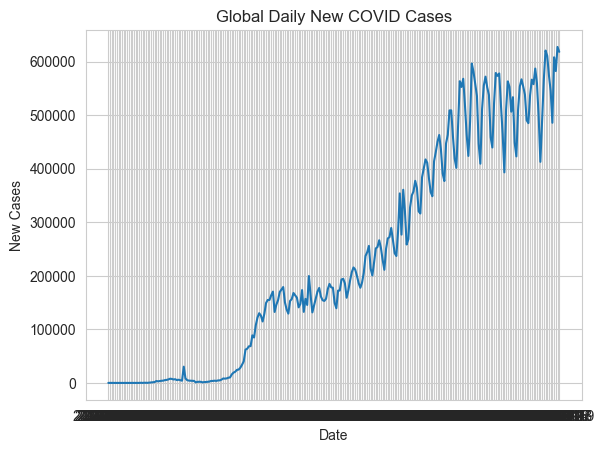

In [12]:
global_cases = df.groupby('date')['new_cases'].sum().reset_index()

sns.lineplot(data=global_cases, x='date', y='new_cases')
plt.title("Global Daily New COVID Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

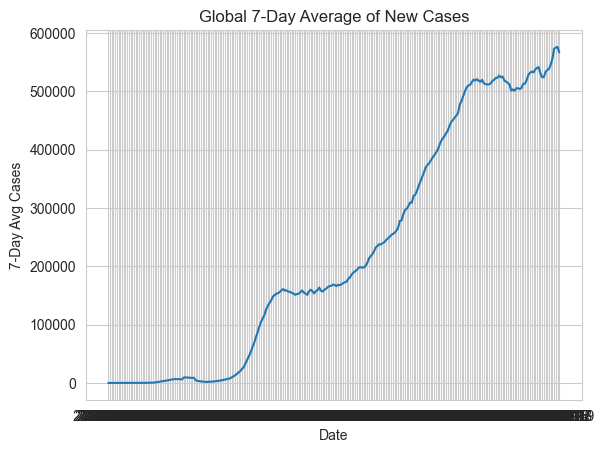

In [13]:
global_avg = df.groupby('date')['new_cases_7day_avg'].sum().reset_index()

sns.lineplot(data=global_avg, x='date', y='new_cases_7day_avg')
plt.title("Global 7-Day Average of New Cases")
plt.xlabel("Date")
plt.ylabel("7-Day Avg Cases")
plt.show()

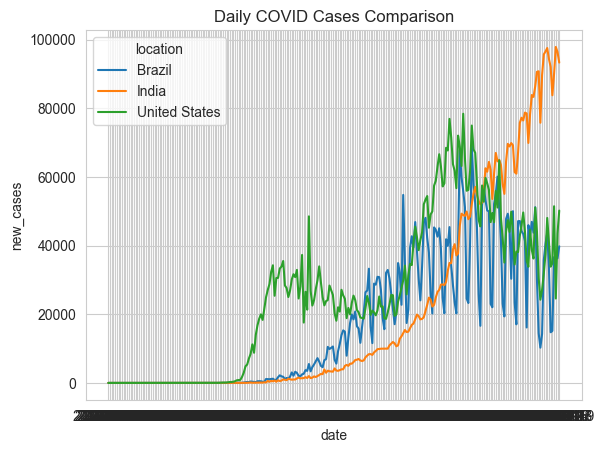

In [17]:
countries = ['India', 'United States', 'Brazil']

country_df = df[df['location'].isin(countries)]

sns.lineplot(
    data=country_df,
    x='date',
    y='new_cases',
    hue='location'
)

plt.title("Daily COVID Cases Comparison")
plt.show()


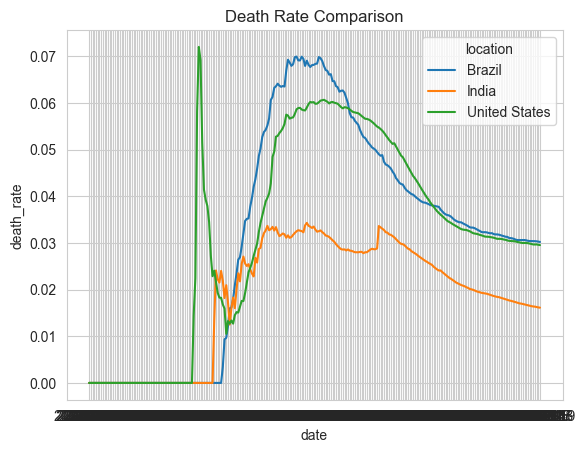

In [18]:
sns.lineplot(
    data=country_df,
    x='date',
    y='death_rate',
    hue='location'
)

plt.title("Death Rate Comparison")
plt.show()

In [20]:
peak_day = global_cases.loc[global_cases['new_cases'].idxmax()]

print("Peak Global Case Day:")
print(peak_day)

Peak Global Case Day:
date         2020-09-18
new_cases      627307.0
Name: 262, dtype: object
